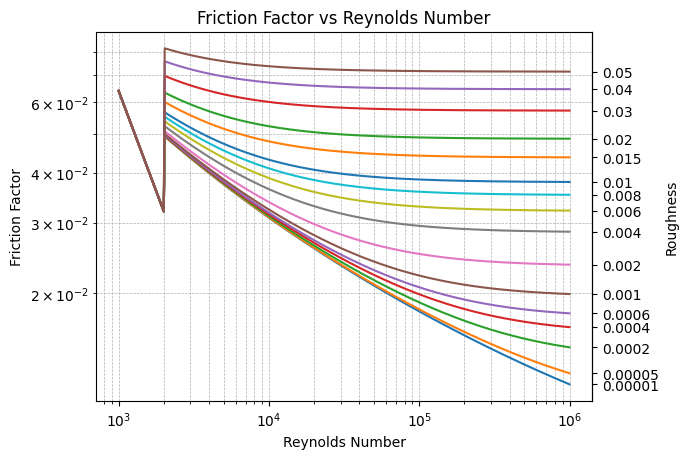

In [50]:
import numpy as np
import scipy as sci
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, NullLocator


def get_friction_factor(reynolds_number, roughness):
    Re = reynolds_number
    if reynolds_number < 2000:
        return 64 / reynolds_number
    # elif reynolds_number < 4000:
        # return 0.5
        # return 0.316 / reynolds_number**0.25
    # return 1
    else:
        # Rstar = lambda f: 1/np.sqrt(8) * roughness * Re*f
        # eq = lambda f: -1/np.sqrt(f) - 1.93 * np.log10(1.91/(Re*np.sqrt(f))*(1+0.34*Rstar(f)*(1-np.exp(-Rstar(f)/26)))) - 0.537
        eq = lambda f: -1/np.sqrt(f) - 2.00*np.log10(2.51/(Re*np.sqrt(f)) + roughness/3.71)
        result = sci.optimize.root_scalar(eq, bracket=[1e-5, 1], method='bisect')
        # print(result)
        return result.root

# get_friction_factor(5000)

fig, ax = plt.subplots()

reynolds_numbers = np.logspace(3, 6, num=500)
roughnesses = [1e-5, 5e-5, 2e-4, 4e-4, 6e-4, 1e-3, 2e-3, 4e-3, 6e-3, 8e-3, 1e-2, 1.5e-2, 2e-2, 3e-2, 4e-2, 5e-2]
# print(np.max(reynolds_numbers))

last_friction_factors = []

for roughness in roughnesses:
    friction_factors = [get_friction_factor(Re, roughness=roughness) for Re in reynolds_numbers]
    last_friction_factors.append(friction_factors[-1])
    ax.plot(reynolds_numbers, friction_factors)


ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Reynolds Number')
ax.set_ylabel('Friction Factor')
ax.set_title('Friction Factor vs Reynolds Number')
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

ax2 = ax.secondary_yaxis('right')
ax2.set_yscale('log')
ax2.set_ylabel('Roughness')
ax2.grid = False
ax2.yaxis.set_major_locator(FixedLocator(last_friction_factors))
ax2.yaxis.set_minor_locator(NullLocator())
ax2.set_yticklabels([f"{r:.6f}".rstrip('0') for r in roughnesses])

plt.show()
